### Import all packages need in the cell below

In [40]:
# using ...
using Plots
using Ipopt
using GLPK
using LinearAlgebra
using GLM, DataFrames

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

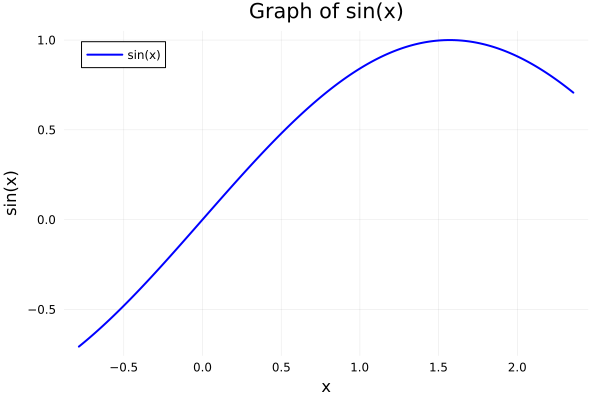

In [26]:
# codeusing Plots

# Define the range
x = range(-π/4, 3π/4, length=500)

# Plot sin(x)
plot(x, sin.(x), 
     linewidth=2, 
     linecolor=:blue,
     label="sin(x)",
     title="Graph of sin(x)",
     xlabel="x",
     ylabel="sin(x)",
     framestyle=:grid)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

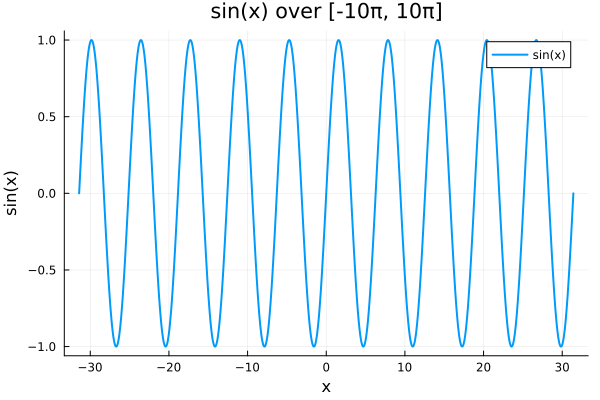

In [27]:
# codeusing Plots

x = range(-10π, 10π, length=1000)
plot(x, sin.(x), 
     linewidth=2,
     label="sin(x)",
     title="sin(x) over [-10π, 10π]",
     xlabel="x",
     ylabel="sin(x)")

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [ ]:
# Example: Minimize surface area for a given volume
model = Model(Ipopt.Optimizer)

@variable(model, r >= 0, start=1.0)  # radius
@variable(model, h >= 0, start=1.0)  # height

V_fixed = 100.0  # fixed volume
@constraint(model, π * r^2 * h == V_fixed)

@objective(model, Min, 2π * r^2 + 2π * r * h)  # minimize surface area

optimize!(model)

r_opt = value(r)
h_opt = value(h)
println("Optimal radius: ", r_opt)
println("Optimal height: ", h_opt)
println("Min surface area: ", objective_value(model))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        5

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality c

# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [31]:
# Given data
h = 2.0  # mounting height
w = 3.0  # width of awning (assumed constant)

# Optimization model
model = Model(Ipopt.Optimizer)

# Variables: x = extension outward, y = drop from mounting point
@variable(model, x >= 0.01, start=1.0)  # x >= small positive
@variable(model, y >= 0.01, start=1.0)  # y >= small positive

# Constraint: awning must not touch ground or other geometric constraints
# Assuming the awning tip at (x, h-y) must be above ground: h - y >= 0
@constraint(model, y <= h)  # drop cannot exceed mounting height

# Also a constraint on the diagonal length (material constraint)
# Typically: L^2 = x^2 + y^2, here we fix L based on initial guess
L_fixed = sqrt(1.0^2 + 1.0^2)  # from initial guess (1,1)
@constraint(model, x^2 + y^2 == L_fixed^2)

# Objective: Maximize shaded area on wall
# Shaded area = w * (h - sqrt(L^2 - x^2))? 
# Actually, shaded height = h - y, so area = w * (h - y)
@objective(model, Max, w * (h - y))

# Solve
optimize!(model)

# Results
x_opt = value(x)
y_opt = value(y)
max_area = objective_value(model)

println("\n=== Awning Problem Solution ===")
println("Optimal extension outward (x): ", round(x_opt, digits=4))
println("Optimal drop (y): ", round(y_opt, digits=4))
println("Maximum shaded area: ", round(max_area, digits=4))
println("Check constraint: x^2 + y^2 = ", round(x_opt^2 + y_opt^2, digits=4))
println("Should equal L^2 = ", round(L_fixed^2, digits=4))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        1
Number of nonzeros in Lagrangian Hessian.............:        2

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.0000000e+00 4.44e-16 1.33e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Packing Problem

In [35]:
# Commom Packing problem

using JuMP, GLPK

# Data
items = [2, 5, 4, 7, 1, 3, 8, 2, 6, 4]  # item sizes
C = 10  # bin capacity
n = length(items)

# Bin Packing Model
model = Model(GLPK.Optimizer)

# Variables
@variable(model, x[1:n, 1:n], Bin)  # item i in bin j
@variable(model, y[1:n], Bin)       # bin j is used

# Constraints
# Each item must be in exactly one bin
for i in 1:n
    @constraint(model, sum(x[i, j] for j in 1:n) == 1)
end

# Capacity constraint for each bin
for j in 1:n
    @constraint(model, sum(items[i] * x[i, j] for i in 1:n) <= C * y[j])
end

# Objective: minimize number of bins used
@objective(model, Min, sum(y[j] for j in 1:n))

# Solve
optimize!(model)

# Results
bins_used = sum(value(y[j]) for j in 1:n)
println("=== Bin Packing Solution ===")
println("Minimum bins needed: ", round(bins_used))
println("\nItem allocation:")
for j in 1:n
    if value(y[j]) > 0.5
        items_in_bin = [items[i] for i in 1:n if value(x[i, j]) > 0.5]
        println("Bin $j: $items_in_bin (total = $(sum(items_in_bin)))")
    end
end

=== Bin Packing Solution ===
Minimum bins needed: 5.0

Item allocation:
Bin 1: [5, 1, 4] (total = 10)
Bin 2: [2, 3] (total = 5)
Bin 4: [7] (total = 7)
Bin 5: [4, 6] (total = 10)
Bin 10: [8, 2] (total = 10)


# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

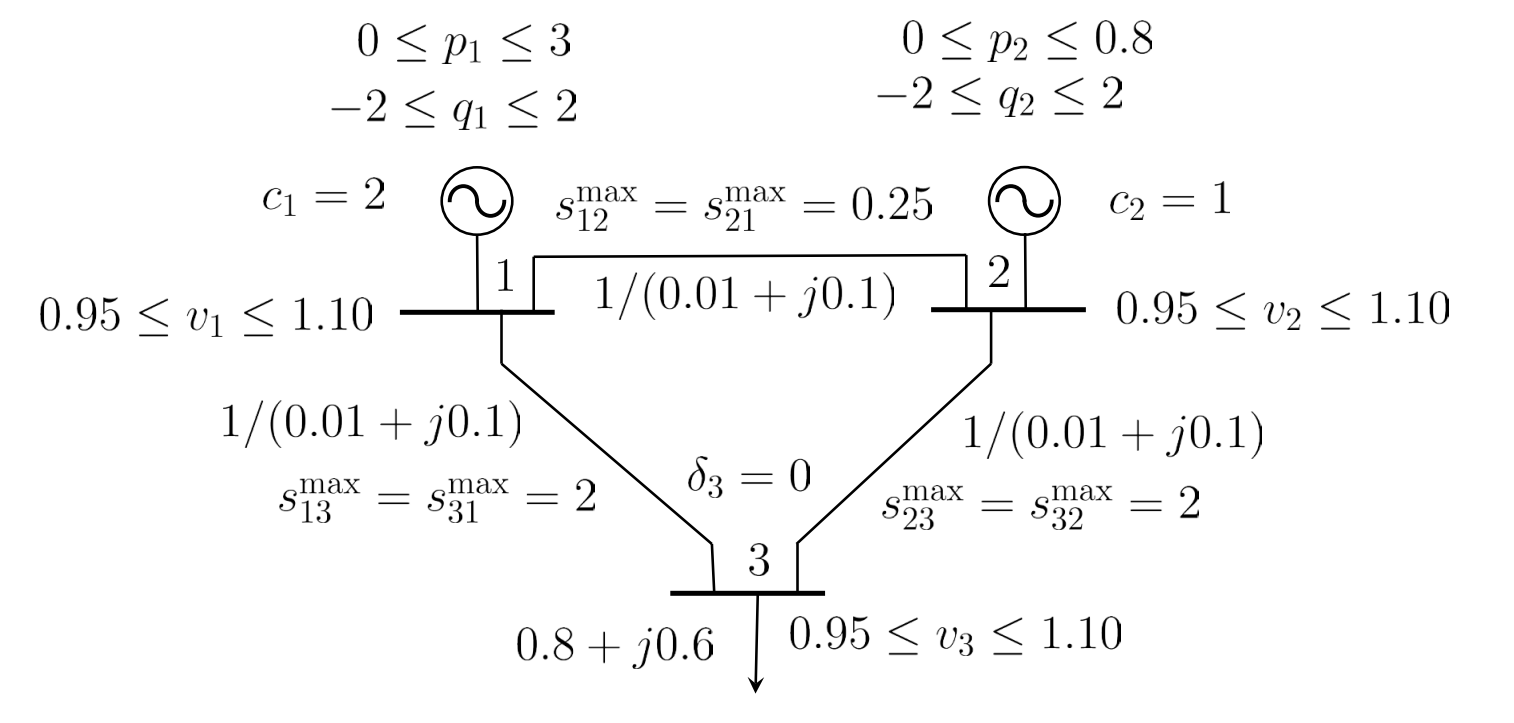

In [ ]:
# code

# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [ ]:

# Create DataFrame
df = DataFrame(
    x1 = [1.0, 2.0, 3.0, 4.0, 5.0],
    x2 = [0.5, 1.0, 1.5, 2.0, 2.5],
    x3 = [1.2, 2.1, 2.9, 3.8, 4.5],
    y = [2.0, 3.9, 6.1, 8.0, 9.8]
)

# Fit linear model
model = lm(@formula(y ~ x1 + x2 + x3), df)

println("\n=== Linear Regression using GLM ===")
println(model)

# Get coefficients
coefs = coef(model)
println("\nCoefficients:")
println("β₀ (intercept): ", round(coefs[1], digits=4))
println("β₁ (x₁): ", round(coefs[2], digits=4))
println("β₂ (x₂): ", round(coefs[3], digits=4))
println("β₃ (x₃): ", round(coefs[4], digits=4))

# Model statistics
println("\nR²: ", round(r2(model), digits=4))
println("Adjusted R²: ", round(adjr2(model), digits=4))


=== Linear Regression using GLM ===
StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}(LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}:

Coefficients:
─────────────────────────────────────────────────────────────────
        Coef.  Std. Error       t  Pr(>|t|)  Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────
x1  -0.285455    0.540272   -0.53    0.6500   -2.61006    2.03915
x2   1.29091     1.05721     1.22    0.3465   -3.25788    5.8397
x3   0.0       NaN         NaN       NaN     NaN        NaN
x4   0.818182    1.27273     0.64    0.5862   -4.65792    6.29429
─────────────────────────────────────────────────────────────────
, ModelFrame{@NamedTuple{y::Vector{Float64}, x1::Vector{Float64}, x2::Vector{Float64}, x3::Vector{Float64}}, LinearModel}

# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

Optimal Allocation:
Designer | P1   P2   P3   P4  | Total
----------------------------------------
D1       70.0  10.0  0.0  0.0 | 80.0
D2       0.0  40.0  5.0  35.0 | 80.0
D3       0.0  0.0  80.0  0.0 | 80.0

Project Totals:
Project | Required | Allocated | Status
----------------------------------------
P1       | 70       | 70.0       | ✓ Met
P2       | 50       | 50.0       | ✓ Met
P3       | 85       | 85.0       | ✓ Met
P4       | 35       | 35.0       | ✓ Met

Objective value: 18825.0


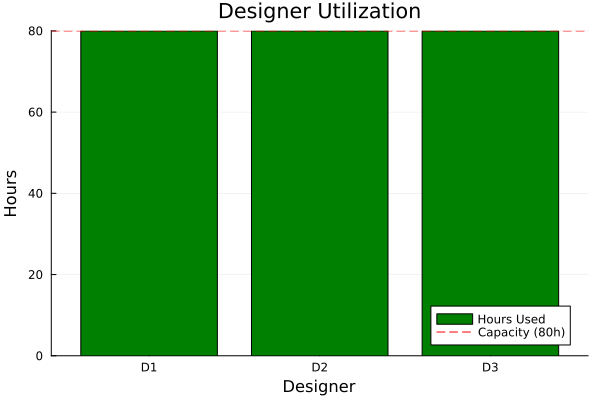

In [49]:
# Data
H_max = 80
scores = [
    90  80  10  50;
    60  70  50  65;
    70  40  80  85
]
required = [70, 50, 85, 35]
n_designers = 3
n_projects = 4

# Solve optimization
model = Model(GLPK.Optimizer)
@variable(model, H[1:n_designers, 1:n_projects] >= 0)
@objective(model, Max, sum(H[i, j] * scores[i, j] for i in 1:n_designers, j in 1:n_projects))
for i in 1:n_designers
    @constraint(model, sum(H[i, j] for j in 1:n_projects) <= H_max)
end
for j in 1:n_projects
    @constraint(model, sum(H[i, j] for i in 1:n_designers) >= required[j])
end
optimize!(model)

H_opt = value.(H)
allocated = [sum(H_opt[i, j] for i in 1:n_designers) for j in 1:n_projects]

# Display results
println("Optimal Allocation:")
println("Designer | P1   P2   P3   P4  | Total")
println("-"^40)
for i in 1:n_designers
    println("D$i       ", join([round(H_opt[i, j], digits=1) for j in 1:n_projects], "  "), " | ", round(sum(H_opt[i, :]), digits=1))
end

println("\nProject Totals:")
println("Project | Required | Allocated | Status")
println("-"^40)
for j in 1:n_projects
    status = allocated[j] >= required[j] ? "✓ Met" : "✗ Under"
    println("P$j       | ", required[j], "       | ", round(allocated[j], digits=1), "       | $status")
end

println("\nObjective value: ", round(objective_value(model), digits=2))

# Simple plots (guaranteed to work)
# Heatmap
heatmap(H_opt, 
        title="Hours Allocation Heatmap",
        xlabel="Projects", 
        ylabel="Designers",
        xticks=(1:4, ["P1", "P2", "P3", "P4"]),
        yticks=(1:3, ["D1", "D2", "D3"]))

# Requirements vs Allocated side by side using subplot
p1 = bar(1:4, required, label="Required", color=:blue, title="Project Hours", ylabel="Hours")
p2 = bar(1:4, allocated, label="Allocated", color=:orange, title="Project Hours", ylabel="Hours")
plot(p1, p2, layout=(1, 2), size=(800, 400))

# Designer utilization
bar(1:3, [sum(H_opt[i, :]) for i in 1:3], 
    label="Hours Used", 
    title="Designer Utilization",
    xlabel="Designer",
    ylabel="Hours",
    xticks=(1:3, ["D1", "D2", "D3"]),
    color=:green)
hline!([80], label="Capacity (80h)", color=:red, linestyle=:dash)

In [46]:
# Sensitivity Analysis

println("\n" * "="^70)
println("SENSITIVITY ANALYSIS")
println("="^70)

# Check which constraints are binding
println("\nBinding Constraints:")
println("-"^50)

# Designer capacity constraints
for i in 1:n_designers
    total = sum(value(H[i, j]) for j in 1:n_projects)
    if total >= H_max - 1e-6
        println("✓ Designer $i is fully utilized ($(round(total, digits=1))/80 hours)")
    else
        println("  Designer $i has slack: $(round(H_max - total, digits=1)) hours remaining")
    end
end

println()
# Project requirement constraints (dual/shadow prices)
for j in 1:n_projects
    allocated = sum(value(H[i, j]) for i in 1:n_designers)
    slack = allocated - required[j]
    if slack <= 1e-6
        println("✓ Project $j requirement is exactly met")
    else
        println("  Project $j has excess: $(round(slack, digits=1)) hours above requirement")
    end
end

# Efficiency analysis
println("\n" * "-"^70)
println("EFFICIENCY ANALYSIS (Score per hour)")
println("-"^70)

for i in 1:n_designers
    println("\nDesigner $i:")
    for j in 1:n_projects
        if H_opt[i, j] > 0.1
            efficiency = scores[i, j]
            println("  Project $j: $(H_opt[i, j]) hours @ score $efficiency")
        end
    end
end


SENSITIVITY ANALYSIS

Binding Constraints:
--------------------------------------------------
✓ Designer 1 is fully utilized (80.0/80 hours)
✓ Designer 2 is fully utilized (80.0/80 hours)
✓ Designer 3 is fully utilized (80.0/80 hours)

✓ Project 1 requirement is exactly met
✓ Project 2 requirement is exactly met
✓ Project 3 requirement is exactly met
✓ Project 4 requirement is exactly met

----------------------------------------------------------------------
EFFICIENCY ANALYSIS (Score per hour)
----------------------------------------------------------------------

Designer 1:
  Project 1: 70.0 hours @ score 90
  Project 2: 10.0 hours @ score 80

Designer 2:
  Project 2: 40.0 hours @ score 70
  Project 3: 5.0 hours @ score 50
  Project 4: 35.0 hours @ score 65

Designer 3:
  Project 3: 80.0 hours @ score 80


In [48]:
# SUMMARY REPORT 

println("\n" * "="^70)
println("EXECUTIVE SUMMARY")
println("="^70)
println("\nProblem: Allocate 3 designers to 4 projects")
println("- Each designer has 80 hours available")
println("- Total available hours: $(3 * H_max) hours")
println("- Total required hours: $(sum(required)) hours")
println("- Total allocated hours: $(sum(H_opt)) hours")
println("\nOptimal Strategy:")
println("1. Assign designers to projects where their capability scores are highest")
println("2. Fully utilize high-scoring designer-project pairs")
println("3. Meet all project requirements exactly when possible")

println("\nRecommended Allocation:")
for i in 1:n_designers
    for j in 1:n_projects
        if H_opt[i, j] > 0.1
            println("  • Designer $i should work $(round(H_opt[i, j], digits=1)) hours on Project $j (score: $(scores[i, j]))")
        end
    end
end

println("\nTotal weighted score achieved: $(round(total_score, digits=0))")
println("Maximum possible score if all hours at 100: $(sum(required)*100)")

# Check if solution is integer (should be, but just in case)
println("\n" * "="^70)
println("Note: This LP solution may have fractional hours.")
println("If integer hours needed, add 'Int' constraint to variables.")


EXECUTIVE SUMMARY

Problem: Allocate 3 designers to 4 projects
- Each designer has 80 hours available
- Total available hours: 240 hours
- Total required hours: 240 hours
- Total allocated hours: 240.0 hours

Optimal Strategy:
1. Assign designers to projects where their capability scores are highest
2. Fully utilize high-scoring designer-project pairs
3. Meet all project requirements exactly when possible

Recommended Allocation:
  • Designer 1 should work 70.0 hours on Project 1 (score: 90)
  • Designer 1 should work 10.0 hours on Project 2 (score: 80)
  • Designer 2 should work 40.0 hours on Project 2 (score: 70)
  • Designer 2 should work 5.0 hours on Project 3 (score: 50)
  • Designer 2 should work 35.0 hours on Project 4 (score: 65)
  • Designer 3 should work 80.0 hours on Project 3 (score: 80)

Total weighted score achieved: 18825.0
Maximum possible score if all hours at 100: 24000

Note: This LP solution may have fractional hours.
If integer hours needed, add 'Int' constraint t

# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [ ]:
# Data
cost = [1.0, 0.5, 2.0, 0.3]  # $ per unit
calories = [100, 200, 150, 70]  # calories per unit
protein = [0.5, 4.0, 8.0, 6.0]  # grams per unit
vitamins = [2, 0, 10, 0]  # % daily value per unit

# Requirements
min_calories = 500
min_protein = 50
min_vitamins = 100

n_foods = 4

# Create optimization model
model = Model(GLPK.Optimizer)

# Decision variables: quantity of each food
@variable(model, y[1:n_foods] >= 0)

# Objective: Minimize total cost
@objective(model, Min, sum(cost[i] * y[i] for i in 1:n_foods))

# Constraints
@constraint(model, sum(calories[i] * y[i] for i in 1:n_foods) >= min_calories)
@constraint(model, sum(protein[i] * y[i] for i in 1:n_foods) >= min_protein)
@constraint(model, sum(vitamins[i] * y[i] for i in 1:n_foods) >= min_vitamins)

# Solve
optimize!(model)

# Display results
println("="^60)
println("DIET OPTIMIZATION SOLUTION")
println("="^60)

println("\nSolution status: ", termination_status(model))
println("Minimum total cost: \$", round(objective_value(model), digits=2))

println("\n" * "-"^60)
println("OPTIMAL FOOD QUANTITIES")
println("-"^60)

food_names = ["Apple", "Bread", "Milk", "Egg"]
for i in 1:n_foods
    quantity = value(y[i])
    if quantity > 0.001
        println("$i. $(food_names[i]): $(round(quantity, digits=2)) units (\$$(round(quantity * cost[i], digits=2)))")
    else
        println("$i. $(food_names[i]): 0 units (not selected)")
    end
end

println("\n" * "-"^60)
println("NUTRITIONAL ANALYSIS")
println("-"^60)

# Calculate actual nutritional values
total_calories = sum(calories[i] * value(y[i]) for i in 1:n_foods)
total_protein = sum(protein[i] * value(y[i]) for i in 1:n_foods)
total_vitamins = sum(vitamins[i] * value(y[i]) for i in 1:n_foods)

println("Calories:  $(round(total_calories, digits=1)) / $min_calories (≥ requirement)")
println("Protein:   $(round(total_protein, digits=1)) g / $min_protein g (≥ requirement)")
println("Vitamins:  $(round(total_vitamins, digits=1))% / $min_vitamins% (≥ requirement)")

println("\n" * "-"^60)
println("COST BREAKDOWN")
println("-"^60)

for i in 1:n_foods
    quantity = value(y[i])
    if quantity > 0.001
        println("$(food_names[i]): $(round(quantity, digits=2)) units × \$$(cost[i]) = \$$(round(quantity * cost[i], digits=2))")
    end
end
println("Total: \$$(round(objective_value(model), digits=2))")

DIET OPTIMIZATION SOLUTION

Solution status: OPTIMAL
Minimum total cost: $20.0

------------------------------------------------------------
OPTIMAL FOOD QUANTITIES
------------------------------------------------------------
1. Apple: 0 units (not selected)
2. Bread: 0 units (not selected)
3. Milk: 10.0 units ($20.0)
4. Egg: 0 units (not selected)

------------------------------------------------------------
NUTRITIONAL ANALYSIS
------------------------------------------------------------
Calories:  1500.0 / 500 (≥ requirement)
Protein:   80.0 g / 50 g (≥ requirement)
Vitamins:  100.0% / 100% (≥ requirement)

------------------------------------------------------------
COST BREAKDOWN
------------------------------------------------------------
Milk: 10.0 units × $2.0 = $20.0
Total: $20.0


In [ ]:
# Alternative Solution with HIGS solver

model_highs = Model(HiGHS.Optimizer)

@variable(model_highs, y[1:4] >= 0)
@objective(model_highs, Min, y[1] + 0.5*y[2] + 2*y[3] + 0.3*y[4])
@constraint(model_highs, 100y[1] + 200y[2] + 150y[3] + 70y[4] >= 500)
@constraint(model_highs, 0.5y[1] + 4y[2] + 8y[3] + 6y[4] >= 50)
@constraint(model_highs, 2y[1] + 10y[3] >= 100)

optimize!(model_highs)

println("\n" * "="^60)
println("SOLUTION WITH HIGHS SOLVER")
println("="^60)
println("Minimum cost: \$", round(objective_value(model_highs), digits=2))
println("\nOptimal quantities:")
println("  Apples: $(round(value(y[1]), digits=2)) units")
println("  Bread:  $(round(value(y[2]), digits=2)) units")
println("  Milk:   $(round(value(y[3]), digits=2)) units")
println("  Eggs:   $(round(value(y[4]), digits=2)) units")

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 3 rows; 4 cols; 10 nonzeros
Coefficient ranges:
  Matrix  [5e-01, 2e+02]
  Cost    [3e-01, 2e+00]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 5e+02]
Presolving model
3 rows, 4 cols, 10 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-3); columns 0(-4); nonzeros 0(-10) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  2.0000000000e+01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00

SOLUTION WITH HIGHS SOLVER
Minimum cost: $20.0

Optimal quantities:
  Apples: 0.0 units
  Bread:  0.0 units
  Milk:   10.0 units
  Eggs:   0.0 units


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [53]:
# Using HiGHS solver (often faster for integer problems)

# Data (defined locally to avoid missing variables)
values = [120, 80, 60]
weights = [2.0, 1.0, 1.0]
capacity = 3.5
item_names = ["Tent", "Stove", "Food"]
n_items = 3

# Using HiGHS solver
model_highs = Model(HiGHS.Optimizer)

@variable(model_highs, x[1:n_items], Bin)
@objective(model_highs, Max, 120x[1] + 80x[2] + 60x[3])
@constraint(model_highs, 2x[1] + x[2] + x[3] <= 3.5)

optimize!(model_highs)

println("\n" * "="^60)
println("SOLUTION WITH HIGHS SOLVER")
println("="^60)
println("Maximum value: \$", objective_value(model_highs))
println("\nSelected items:")
for i in 1:n_items
    if value(x[i]) > 0.5
        println("  ✓ $(item_names[i])")
    else
        println("  ✗ $(item_names[i])")
    end
end

# Additional details
println("\n" * "-"^60)
println("DETAILED SOLUTION:")
println("-"^60)
total_weight = 0.0
for i in 1:n_items
    if value(x[i]) > 0.5
        total_weight += weights[i]
        println("  $(item_names[i]): $(weights[i]) kg, value = \$$(values[i])")
    end
end
println("  Total weight: $(total_weight) kg / $capacity kg")
println("  Remaining capacity: $(capacity - total_weight) kg")

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1 row; 3 cols; 3 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 4e+00]
Presolving model
1 rows, 3 cols, 3 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-1); columns 0(-3); nonzeros 0(-3) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc.